In [1]:
import pandas as pd
from google.cloud import bigquery
from google.oauth2 import service_account

credentials = service_account.Credentials.from_service_account_file("key.json") # lokalizacja pobranego klucza z punktu 1.4.

client = bigquery.Client(credentials=credentials, project=credentials.project_id)

In [2]:
query = """

select r20_21.*, stations.*

from (

select *
from `bigquery-public-data.noaa_gsod.gsod2020`

union all

select *
from `bigquery-public-data.noaa_gsod.gsod2021`

) as r20_21
join `bigquery-public-data.noaa_gsod.stations` as stations on r20_21.stn = stations.usaf and r20_21.wban = stations.wban
"""

query_job = client.query(query)
query_result = query_job.result()
# weather and stations
dfwas = query_result.to_dataframe()

Część 1

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = dfwas.copy()
data["date"] = pd.to_datetime(data["date"], errors="coerce")
data["month"] = data["date"].dt.month
data["mxpsd"] = pd.to_numeric(data["mxpsd"], errors="coerce")

missing_codes = {
    "temp": 9999.9,
    "max": 9999.9,
    "min": 9999.9,
    "dewp": 9999.9,
    "slp": 9999.9,
    "stp": 9999.9,
    "visib": 999.9,
    "wdsp": 999.9,
    "mxpsd": 999.9,
    "gust": 999.9,
    "prcp": 99.99
}

for col, code in missing_codes.items():
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors="coerce")
        data[col] = data[col].replace(code, np.nan)

sns.set(style="whitegrid")

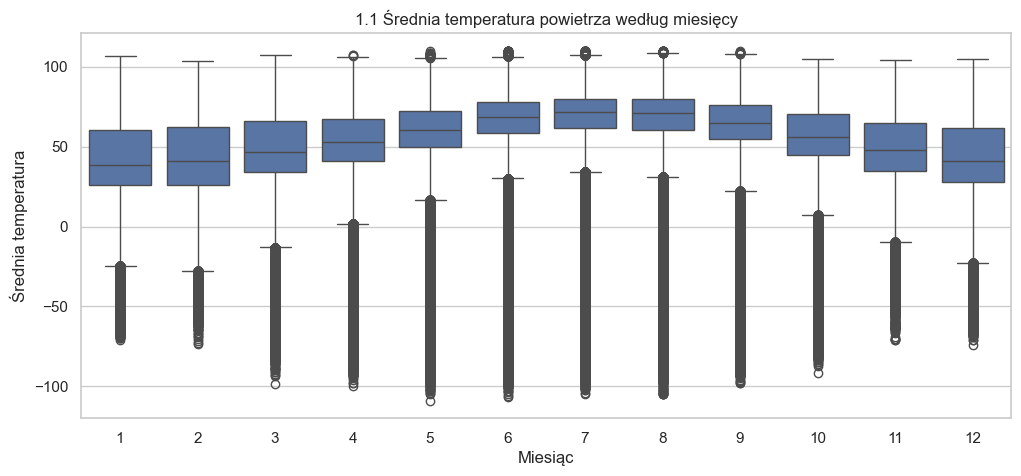

In [4]:
#1.1
plt.figure(figsize=(12, 5))
sns.boxplot(x="month", y="temp", data=data)
plt.title("1.1 Średnia temperatura powietrza według miesięcy")
plt.xlabel("Miesiąc")
plt.ylabel("Średnia temperatura")
plt.show()

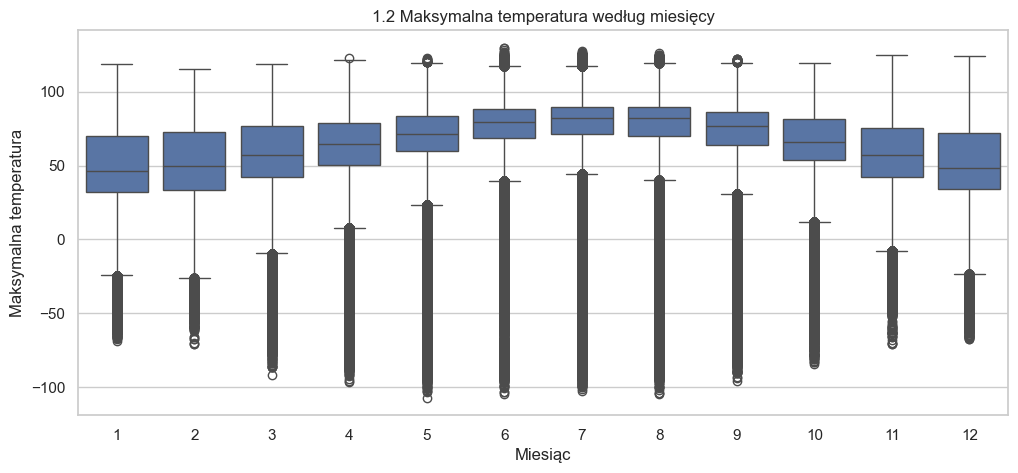

In [5]:
#1.2
plt.figure(figsize=(12, 5))
sns.boxplot(x="month", y="max", data=data)
plt.title("1.2 Maksymalna temperatura według miesięcy")
plt.xlabel("Miesiąc")
plt.ylabel("Maksymalna temperatura")
plt.show()

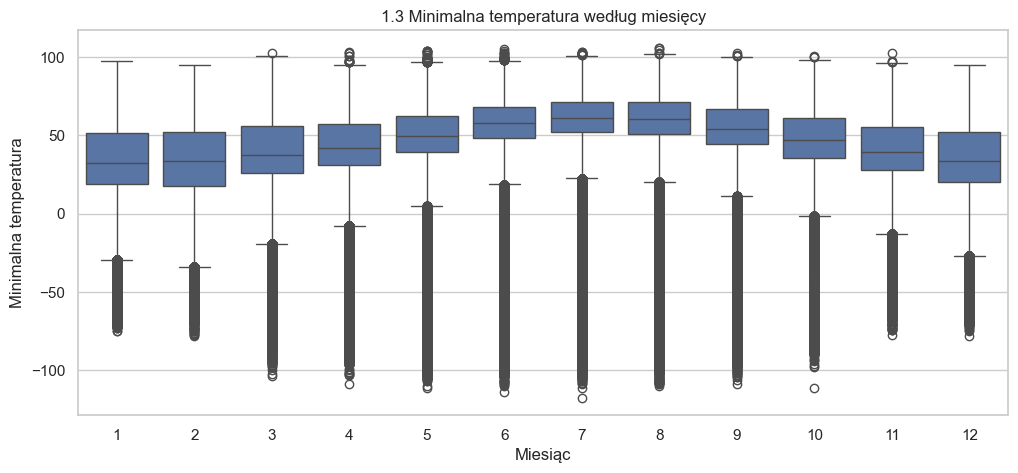

In [6]:
#1.3
plt.figure(figsize=(12, 5))
sns.boxplot(x="month", y="min", data=data)
plt.title("1.3 Minimalna temperatura według miesięcy")
plt.xlabel("Miesiąc")
plt.ylabel("Minimalna temperatura")
plt.show()

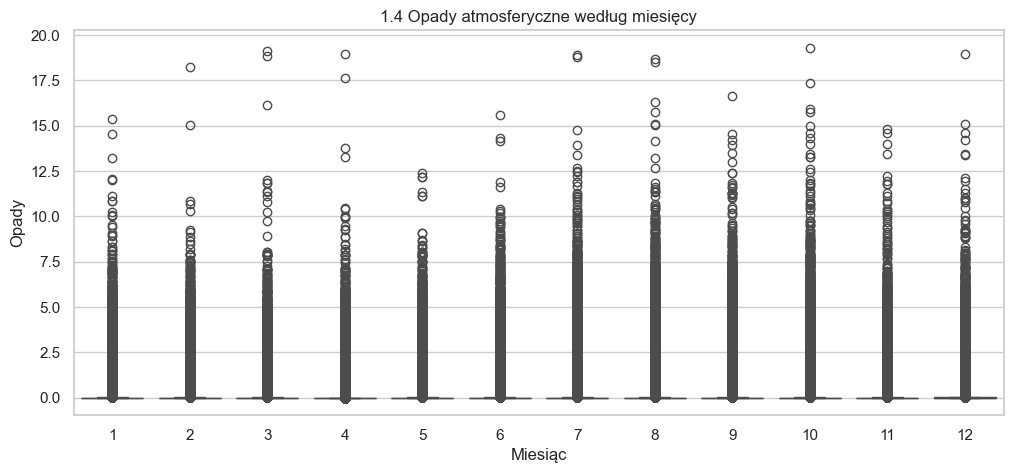

In [7]:
#1.4
plt.figure(figsize=(12, 5))
sns.boxplot(x="month", y="prcp", data=data)
plt.title("1.4 Opady atmosferyczne według miesięcy")
plt.xlabel("Miesiąc")
plt.ylabel("Opady")
plt.show()

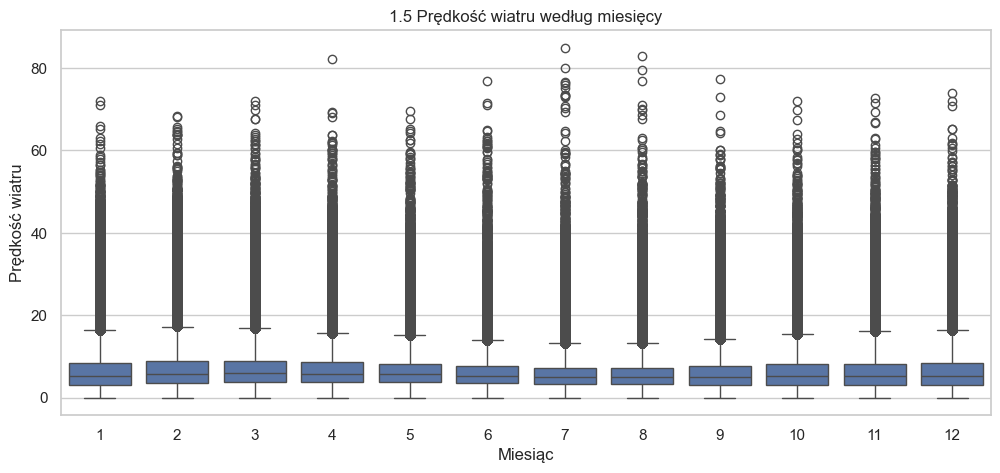

In [8]:
#1.5
plt.figure(figsize=(12, 5))
sns.boxplot(x="month", y="wdsp", data=data)
plt.title("1.5 Prędkość wiatru według miesięcy")
plt.xlabel("Miesiąc")
plt.ylabel("Prędkość wiatru")
plt.show()

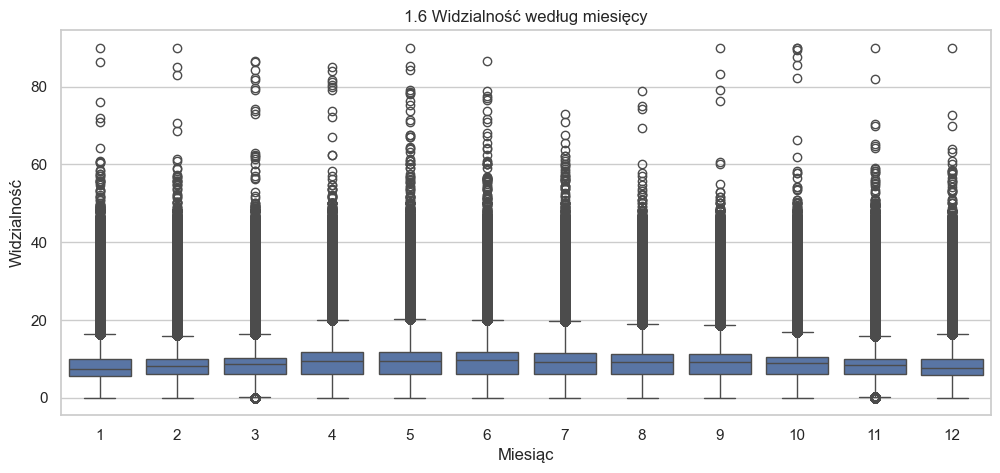

In [9]:
#1.6
plt.figure(figsize=(12, 5))
sns.boxplot(x="month", y="visib", data=data)
plt.title("1.6 Widzialność według miesięcy")
plt.xlabel("Miesiąc")
plt.ylabel("Widzialność")
plt.show()

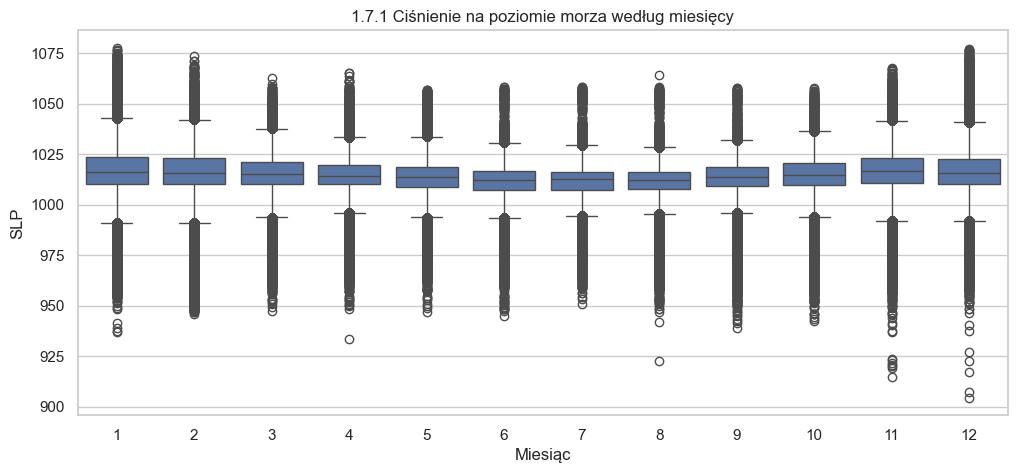

In [10]:
#1.7.1
plt.figure(figsize=(12, 5))
sns.boxplot(x="month", y="slp", data=data)
plt.title("1.7.1 Ciśnienie na poziomie morza według miesięcy")
plt.xlabel("Miesiąc")
plt.ylabel("SLP")
plt.show()

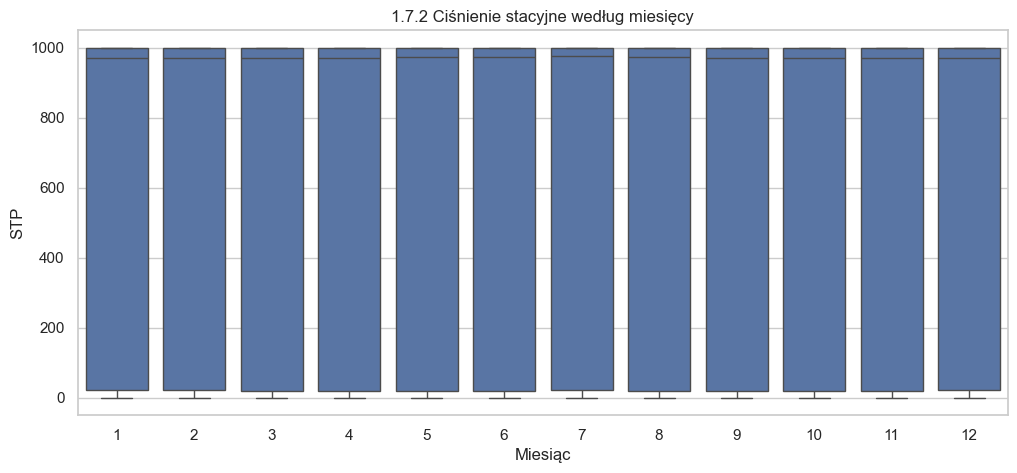

In [11]:
#1.7.2
plt.figure(figsize=(12, 5))
sns.boxplot(x="month", y="stp", data=data)
plt.title("1.7.2 Ciśnienie stacyjne według miesięcy")
plt.xlabel("Miesiąc")
plt.ylabel("STP")
plt.show()

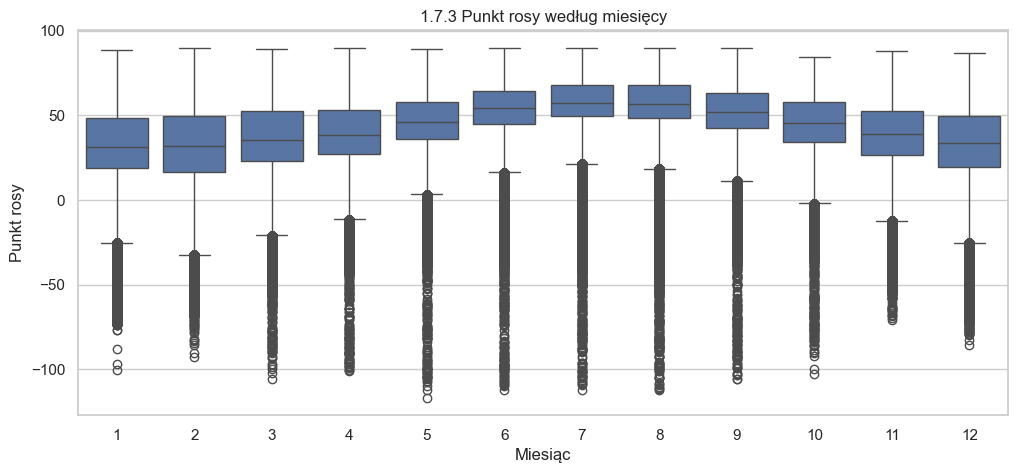

In [12]:
#1.7.3
plt.figure(figsize=(12, 5))
sns.boxplot(x="month", y="dewp", data=data)
plt.title("1.7.3 Punkt rosy według miesięcy")
plt.xlabel("Miesiąc")
plt.ylabel("Punkt rosy")
plt.show()

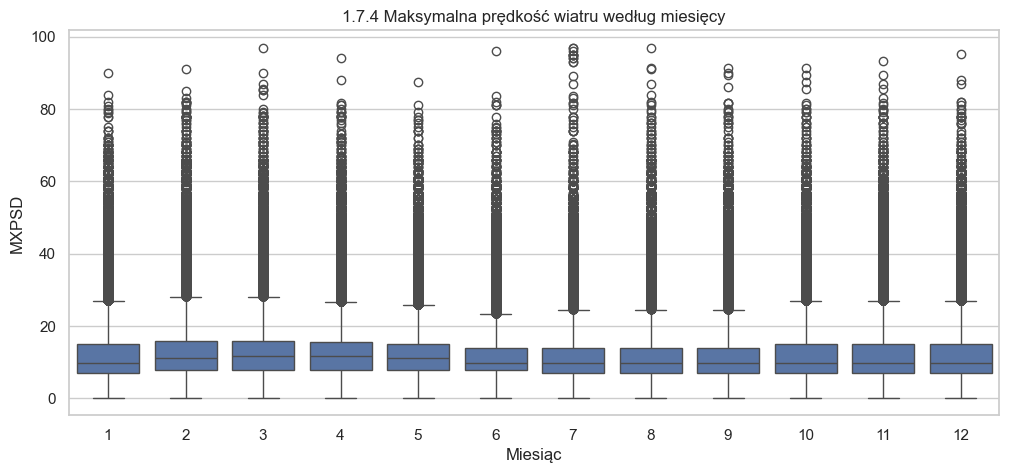

In [13]:
#1.7.4
plt.figure(figsize=(12, 5))
sns.boxplot(x="month", y="mxpsd", data=data)
plt.title("1.7.4 Maksymalna prędkość wiatru według miesięcy")
plt.xlabel("Miesiąc")
plt.ylabel("MXPSD")
plt.show()

Część 2

In [38]:
#średnia temperatura oraz prędkość wiatru
if 'month' not in data.columns:
    data["month"] = data["date"].dt.month

zmienne_do_analizy = ["temp", "wdsp"]

for col in zmienne_do_analizy:
    print(col)
    for month in sorted(data["month"].unique()):
        monthly_data = data[data["month"] == month][col].dropna()

        Q1 = monthly_data.quantile(0.25)
        Q3 = monthly_data.quantile(0.75)
        IQR = Q3 - Q1

        min_normal = Q1 - 1.5 * IQR
        max_normal = Q3 + 1.5 * IQR

        outliers_lower = []
        outliers_upper = []
        for md in monthly_data:
            if md < min_normal:
                outliers_lower.append(md)
            elif md > max_normal:
                outliers_upper.append(md)

        print(f"Miesiąc {month}: Znaleziono {len(outliers_lower) + len(outliers_upper)} outlierów (Zakres: {min_normal:.4f} do {max_normal:.4f})")

        if len(outliers_lower):
            print(f"Min: {min(outliers_lower)}")

        if len(outliers_upper):
            print(f"Max: {max(outliers_upper)}")

# po prześledzeniu wyników wydaje się, że outliery to wartości skrajne wynikające z rzeczywistych zjawisk pogodowych.
# na podstawie przeprowadzonej analizy postanowiłem pozostawić je w zbiorze danych.

temp
Miesiąc 1: Znaleziono 11526 outlierów (Zakres: -24.8500 do 111.5500)
Min: -71.0
Miesiąc 2: Znaleziono 6885 outlierów (Zakres: -28.0000 do 116.0000)
Min: -73.6
Miesiąc 3: Znaleziono 9467 outlierów (Zakres: -13.1000 do 113.3000)
Min: -98.3
Miesiąc 4: Znaleziono 7677 outlierów (Zakres: 1.8000 do 106.6000)
Min: -99.6
Max: 107.3
Miesiąc 5: Znaleziono 5613 outlierów (Zakres: 16.4500 do 105.6500)
Min: -109.0
Max: 110.0
Miesiąc 6: Znaleziono 5484 outlierów (Zakres: 30.0500 do 106.4500)
Min: -106.9
Max: 110.0
Miesiąc 7: Znaleziono 6869 outlierów (Zakres: 34.4000 do 107.2000)
Min: -104.8
Max: 110.0
Miesiąc 8: Znaleziono 4663 outlierów (Zakres: 31.2000 do 108.8000)
Min: -105.0
Max: 110.0
Miesiąc 9: Znaleziono 3813 outlierów (Zakres: 22.4000 do 108.0000)
Min: -98.1
Max: 109.6
Miesiąc 10: Znaleziono 4880 outlierów (Zakres: 7.0500 do 108.2500)
Min: -91.9
Miesiąc 11: Znaleziono 6500 outlierów (Zakres: -9.8000 do 109.4000)
Min: -70.9
Miesiąc 12: Znaleziono 11047 outlierów (Zakres: -23.1000 do 112

Część 3

In [15]:
data = dfwas.copy()

data["date"] = pd.to_datetime(data["date"], errors="coerce")

print(data.dtypes)

stn                             object
wban                            object
date                    datetime64[ns]
year                            object
mo                              object
da                              object
temp                           float64
count_temp                       Int64
dewp                           float64
count_dewp                       Int64
slp                            float64
count_slp                        Int64
stp                            float64
count_stp                        Int64
visib                          float64
count_visib                      Int64
wdsp                            object
count_wdsp                      object
mxpsd                           object
gust                           float64
max                            float64
flag_max                        object
min                            float64
flag_min                        object
prcp                           float64
flag_prcp                

In [16]:
#3.2
weather_cols = ["temp", "max", "min", "prcp", "wdsp", "visib", "slp", "stp", "dewp", "mxpsd"]

for col in weather_cols:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors="coerce")

if "temp" in data.columns:
    data["temp"] = data["temp"].replace(9999.9, np.nan)
if "max" in data.columns:
    data["max"] = data["max"].replace(9999.9, np.nan)
if "min" in data.columns:
    data["min"] = data["min"].replace(9999.9, np.nan)
if "dewp" in data.columns:
    data["dewp"] = data["dewp"].replace(9999.9, np.nan)
if "slp" in data.columns:
    data["slp"] = data["slp"].replace(9999.9, np.nan)
if "stp" in data.columns:
    data["stp"] = data["stp"].replace(9999.9, np.nan)

if "visib" in data.columns:
    data["visib"] = data["visib"].replace(999.9, np.nan)
if "wdsp" in data.columns:
    data["wdsp"] = data["wdsp"].replace(999.9, np.nan)
if "mxpsd" in data.columns:
    data["mxpsd"] = data["mxpsd"].replace(999.9, np.nan)

if "prcp" in data.columns:
    data["prcp"] = data["prcp"].replace(99.99, np.nan)


#################         Zostało to już zrobionie w trakcie podpunku 1    ################################

In [40]:
#3.1
missing_summary = pd.DataFrame({
    "liczba_brakow": data.isna().sum(),
    "procent_brakow": round(data.isna().sum() / len(data) * 100, 2)
})

missing_summary = missing_summary.sort_values("liczba_brakow", ascending=False)
missing_summary

,liczba_brakow,procent_brakow
state,6207545,76.45
gust,5788304,71.29
flag_min,4913008,60.51
flag_max,4786959,58.96
call,3926108,48.35
slp,2794527,34.42
visib,2169612,26.72
prcp,604290,7.44
flag_prcp,604290,7.44
mxpsd,462639,5.70


In [18]:
#3.3
data = data.sort_values("date").copy()

selected_cols = ["wdsp", "prcp"]

data_mean = data.copy()
data_median = data.copy()
data_interp = data.copy()

# imputacja średnią
for col in selected_cols:
    data_mean[col] = data_mean[col].fillna(data_mean[col].mean())

# imputacja medianą
for col in selected_cols:
    data_median[col] = data_median[col].fillna(data_median[col].median())

#interpolacja w czasie
data_interp = data_interp.set_index("date")

for col in selected_cols:
    data_interp[col] = data_interp[col].interpolate(method="time")

data_interp = data_interp.reset_index()

In [19]:
#3.4
for col in selected_cols:
    print(f"\n===== {col.upper()} =====")

    print("\nOryginalne dane:")
    print(data[col].describe())

    print("\nPo imputacji średnią:")
    print(data_mean[col].describe())

    print("\nPo imputacji medianą:")
    print(data_median[col].describe())

    print("\nPo interpolacji w czasie:")
    print(data_interp[col].describe())


#################  Można by było dodać jakiś opis, która jest bardziej odpowiednia czy coś ###########################


===== WDSP =====

Oryginalne dane:
count    7.797877e+06
mean     6.340804e+00
std      4.434327e+00
min      0.000000e+00
25%      3.400000e+00
50%      5.300000e+00
75%      8.200000e+00
max      8.490000e+01
Name: wdsp, dtype: float64

Po imputacji średnią:
count    8.119543e+06
mean     6.340804e+00
std      4.345604e+00
min      0.000000e+00
25%      3.500000e+00
50%      5.500000e+00
75%      8.000000e+00
max      8.490000e+01
Name: wdsp, dtype: float64

Po imputacji medianą:
count    8.119543e+06
mean     6.299571e+00
std      4.350343e+00
min      0.000000e+00
25%      3.500000e+00
50%      5.300000e+00
75%      8.000000e+00
max      8.490000e+01
Name: wdsp, dtype: float64

Po interpolacji w czasie:
count    8.119543e+06
mean     6.337858e+00
std      4.426651e+00
min      0.000000e+00
25%      3.400000e+00
50%      5.300000e+00
75%      8.200000e+00
max      8.490000e+01
Name: wdsp, dtype: float64

===== PRCP =====

Oryginalne dane:
count    7.515253e+06
mean     7.583993e-02

Część 4


4.1. Średnie wartości dla lipca
   country       temp      prcp      wdsp
0      CH  76.014621  0.192550  4.979705
1      CI  47.581171  0.072991  6.249272
2      IR  88.334638  0.010028  7.242303
3      PL  66.538817  0.088442  5.776602
4      QA  97.012212  0.001313  6.933180
5      RI  72.411183  0.102868  4.035865
6      RS  64.071135  0.082099  5.048661
7      SP  75.157067  0.024333  6.551839
8      SZ  60.963903  0.173184  4.748422
9      US  74.542821  0.080344  5.414362:

4.2. Średnia dzienna zmiana w lipcu :
  country  temp_change  prcp_change
0      CH     0.079083    -0.001775
1      CI     0.030387    -0.002279
2      IR    -0.016615     0.000150
3      PL    -0.067687    -0.007315
4      QA     0.068664     0.000000
5      RI     0.061505    -0.001181
6      RS     0.001491     0.000379
7      SP     0.060884    -0.000026
8      SZ     0.264786    -0.004443
9      US     0.010671    -0.001918:

4.3. Mediana wartości dla lipca 
  country  temp  prcp  wdsp
0      CH  77.9 

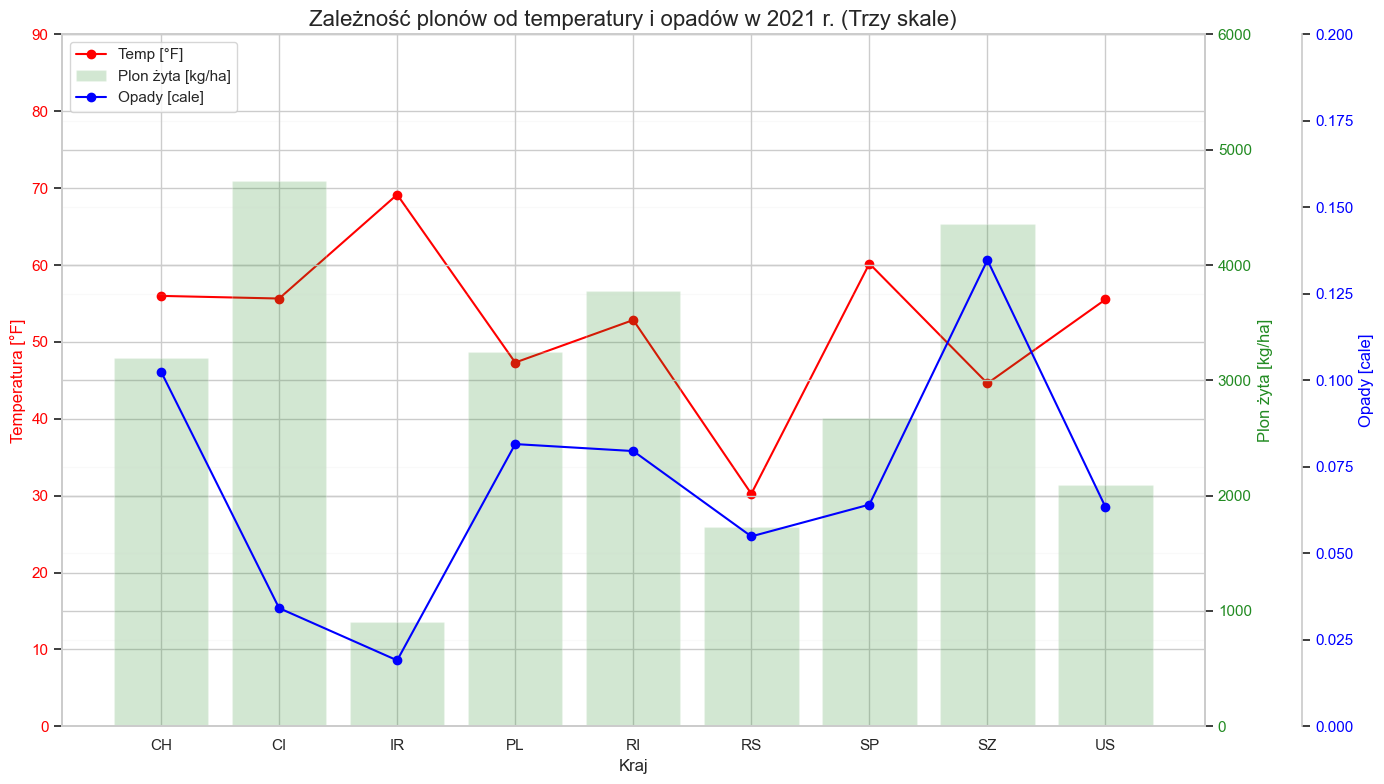

In [58]:
# Obliczenia statystyczne (m.in. średnia, mediana, moda, odchylenie standardowe) pozwalają na zrozumienie rozkładu danych oraz na identyfikację ewentualnych anomalii lub nietypowych wartości.

# 4.1. średnia temperatura, opady i prędkość wiatru dla co najmniej 10 wybranych krajów lub stacji w wybranym miesiącu,


# "PL": "Poland",
# "QA": "Qatar",
# "RI": "Serbia",
# "SP": "Spain",
# "SZ": "Switzerland",
# 'IR': 'iran (islamic republic of)',
# "US": "United States of America",
# 'ch': 'china, mainland',
# "CI": "Chile",
# "RS": "Russian Federation"

countries_to_check = ["PL", "QA", "RI", "SP", "SZ", "IR", "US", "CH", "CI", "RS"]
data['month'] = data['date'].dt.month
df_lip = data[(data['month'] == 7) & (data['country'].isin(countries_to_check))]
df_4_1 = df_lip.groupby('country')[['temp', 'prcp', 'wdsp']].mean().reset_index()

print(f"\n4.1. Średnie wartości dla lipca\n {df_4_1}:")

# 4.2. średnia zmiana temperatury i opadów dla co najmniej 10 wybranych krajów lub stacji w wybranym miesiącu,

data = data.sort_values(['stn', 'date'])
data['temp_change'] = data.groupby('stn')['temp'].diff()
data['prcp_change'] = data.groupby('stn')['prcp'].diff()
df_lip = data[(data['month'] == 7) & (data['country'].isin(countries_to_check))]

df_4_2 = df_lip.groupby('country')[['temp_change', 'prcp_change']].mean().reset_index()

print(f"\n4.2. Średnia dzienna zmiana w lipcu :\n{df_4_2}:")


# 4.3. mediana temperatury, opadów i prędkości wiatru dla co najmniej 10 wybranych krajów lub stacji w wybranym miesiącu,
df_4_3 = df_lip.groupby('country')[['temp', 'prcp', 'wdsp']].median().reset_index()

print(f"\n4.3. Mediana wartości dla lipca \n{df_4_3}:")

# 4.4. odchylenie standardowe temperatury, opadów i prędkości wiatru,
df_4_4 = df_lip[['temp', 'prcp', 'wdsp']].std()
print(f"\n4.4. Odchylenie standardowe: \n{df_4_4}:")

# 4.5. minimalna, średnia i maksymalna temperatury, opadów i prędkości wiatru dla co najmniej 10 wybranych krajów,
df_4_5 = df_lip.groupby('country').agg({
    'temp': ['min', 'mean', 'max'],
    'prcp': ['min', 'mean', 'max'],
    'wdsp': ['min', 'mean', 'max']
})
print(f"\n4.5. Zestawienie Min/Średnia/Max: \n{df_4_5}:")


# Skorzystaj ze swojego połączonego zbioru danych (pogoda + rolnictwo) i oblicz średnią temperaturę oraz sumę opadów w wybranym roku dla co najmniej 10 krajów, a następnie porównaj te wartości z produkcją lub plonem wybranej rośliny w tych krajach. Spróbuj ocenić, czy można zauważyć zależność pomiędzy warunkami pogodowymi a produkcją rolną.

df_4_6 = pd.read_csv('df_merged.csv')
df_4_6 = df_4_6[df_4_6['country'].isin(countries_to_check) & (df_4_6['year'] == 2021) & (df_4_6['Item'] == 'Rye') &
                (df_4_6['Unit'] == 'kg/ha')]
sf4_6 = df_4_6.groupby('country')[['temp', 'prcp', 'Value']].mean()


# Przygotuj wykresy w celu porównania otrzymanych wyników. Pamiętaj o ich czytelności (typ wykresu, tytuł wykresu, podpisy osi, odpowiednie zakresy osi, itp.). Przeanalizuj otrzymane wizualizacje.
fig, ax1 = plt.subplots(figsize=(14, 8))

# temp
ax1.plot(sf4_6.index, sf4_6['temp'], color='red', marker='o', label='Temp [°F]')
ax1.set_ylabel('Temperatura [°F]', color='red', fontsize=12)
ax1.set_ylim(0, 90)
ax1.tick_params(axis='y', labelcolor='red')

# żyto
ax2 = ax1.twinx()
ax2.bar(sf4_6.index, sf4_6['Value'], color='forestgreen', alpha=0.2, label='Plon żyta [kg/ha]')
ax2.set_ylabel('Plon żyta [kg/ha]', color='forestgreen', fontsize=12)
ax2.set_ylim(0, 6000)
ax2.tick_params(axis='y', labelcolor='forestgreen')

# Opady
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 70))
ax3.plot(sf4_6.index, sf4_6['prcp'], color='blue', marker='o', label='Opady [cale]')
ax3.set_ylabel('Opady [cale]', color='blue', fontsize=12)
ax3.set_ylim(0, 0.2)
ax3.tick_params(axis='y', labelcolor='blue')

ax1.set_xlabel('Kraj', fontsize=12)
plt.title('Zależność plonów od temperatury i opadów w 2021 r. (Trzy skale)', fontsize=16)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc='upper left')

plt.tight_layout()
plt.grid(axis='y', alpha=0.1)
plt.show()

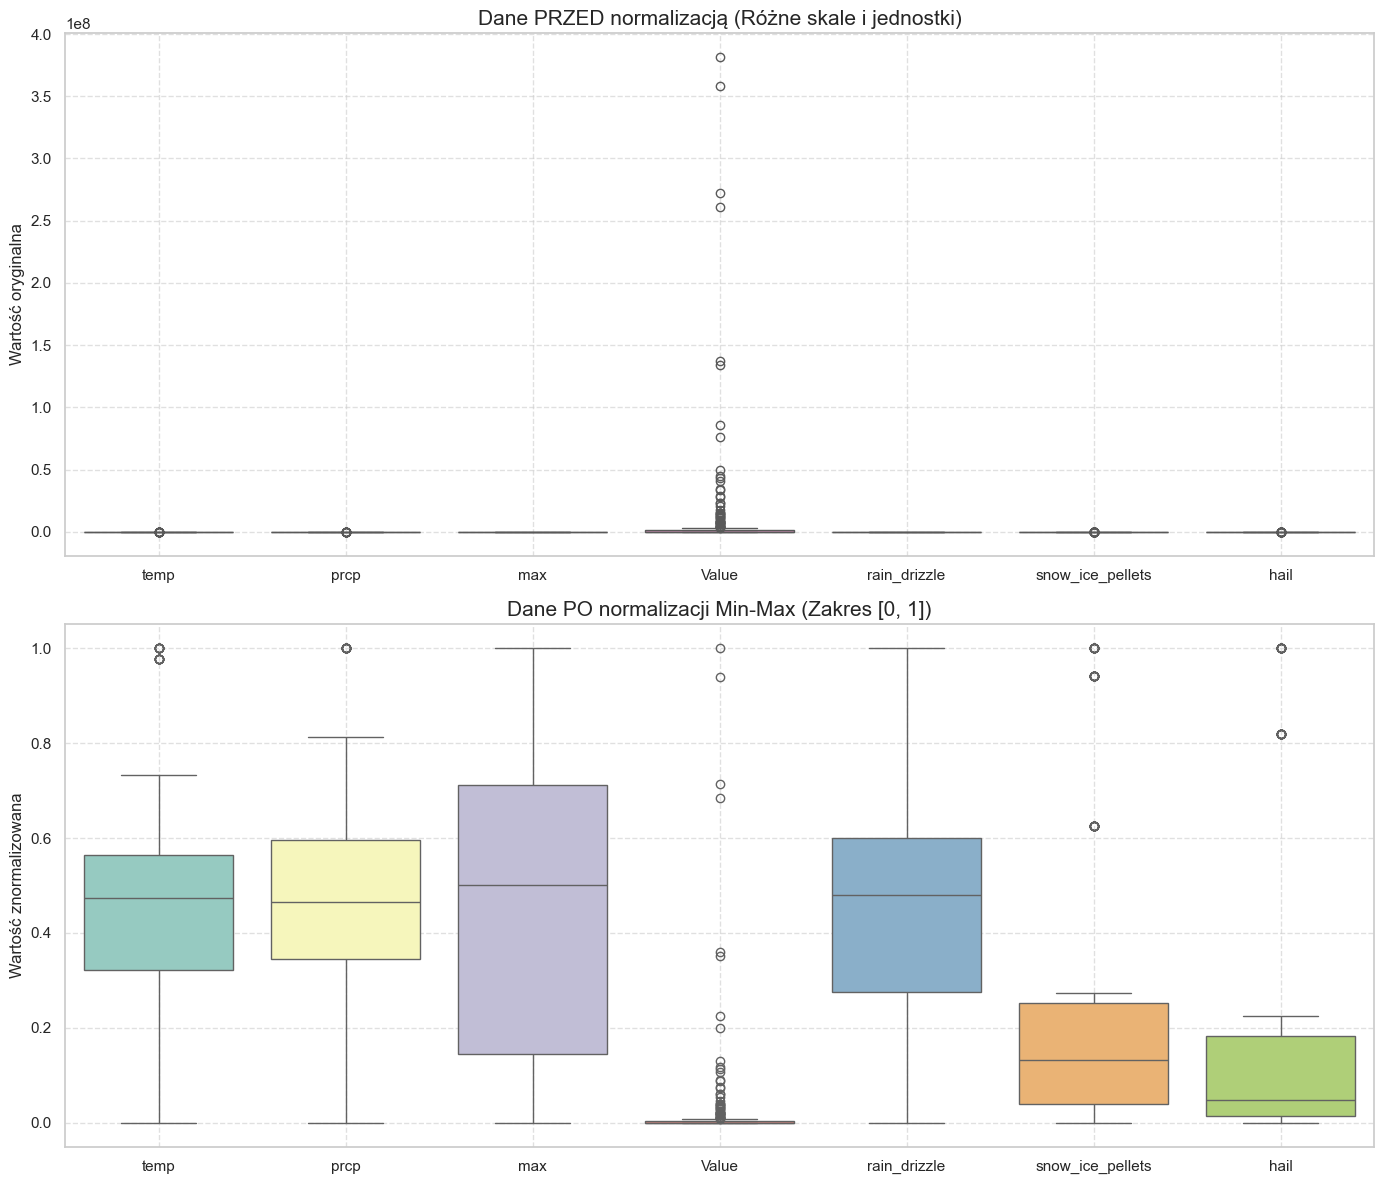

In [21]:
# Normalizacja danych polega na przeskalowaniu wartości zmiennych do określonego zakresu, np. [0, 1], co ułatwia porównanie różnych zmiennych między sobą.
#
# Wykonaj normalizację wybranych zmiennych przy użyciu tej samej metody skalowania (np. normalizacji min-max z zakresu [0,1]):

# 5.1. temperatura,
# 5.2. opady,
# 5.3. prędkość wiatru
# 5.4. wybrana zmienna rolnicza,
# 5.5. co najmniej 3 dodatkowe zmienne, które uznasz za istotne.
df_5 = pd.read_csv('df_merged.csv')
df_5 = df_5[['country', 'temp', 'prcp', 'max', 'Value', 'rain_drizzle', 'snow_ice_pellets', 'hail']]
df_5 = df_5[(df_5['country'].isin(countries_to_check))].reset_index(drop=True)

df_5_normalized = df_5.copy()
for col in df_5_normalized.columns:
    if col != 'country':
        wmax = df_5_normalized[col].max()
        wmin = df_5_normalized[col].min()
        if wmax != wmin:
            for i in range(len(df_5_normalized)):
                df_5_normalized.loc[i, col] = (df_5_normalized.loc[i, col] - wmin) / (wmax - wmin)
        else:
            for i in range(len(df_5_normalized)):
                df_5_normalized.loc[i, col] = 0.0

# Przygotuj wykresy w celu porównania otrzymanych wyników przed i po normalizacji. Pamiętaj o ich czytelności (typ wykresu, tytuł wykresu, podpisy osi, odpowiednie zakresy osi, itp.). Przeanalizuj otrzymane wizualizacje i oceń czy normalizacja ułatwia porównywanie różnych zmiennych.


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

sns.boxplot(data=df_5.drop(columns='country'), ax=ax1, palette="Set2")
ax1.set_title('Dane PRZED normalizacją (Różne skale i jednostki)', fontsize=15)
ax1.set_ylabel('Wartość oryginalna')
ax1.grid(True, linestyle='--', alpha=0.6)

sns.boxplot(data=df_5_normalized.drop(columns='country'), ax=ax2, palette="Set3")
ax2.set_title('Dane PO normalizacji Min-Max (Zakres [0, 1])', fontsize=15)
ax2.set_ylabel('Wartość znormalizowana')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()



Część 6

In [59]:
import seaborn as sns
df_2 = pd.read_csv('df_merged.csv')
df_3 = pd.read_csv('df_weather_co2.csv')
df = pd.read_csv('dfp5.csv')
print(df.dtypes) ## Rzuca błędem:
#
# C:\Users\Asus\AppData\Local\Temp\ipykernel_9312\1220673008.py:4: DtypeWarning: Columns (0,16) have mixed types. Specify dtype option on import or set low_memory=False.
#   df = pd.read_csv('dfp5.csv')

C:\Users\Asus\AppData\Local\Temp\ipykernel_9312\4131461786.py:4: DtypeWarning: Columns (0,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('dfp5.csv')


stn                      object
wban                      int64
date                     object
da                        int64
mo                        int64
year                      int64
temp                    float64
min                     float64
max                     float64
prcp                    float64
flag_prcp                object
wdsp                    float64
mxpsd                   float64
gust                    float64
name                     object
country                  object
state                    object
lat                     float64
lon                     float64
elev                    float64
fog                       int64
rain_drizzle              int64
snow_ice_pellets          int64
hail                      int64
thunder                   int64
tornado_funnel_cloud      int64
sndp                    float64
dtype: object


In [60]:
print(df.columns.tolist())

['stn', 'wban', 'date', 'da', 'mo', 'year', 'temp', 'min', 'max', 'prcp', 'flag_prcp', 'wdsp', 'mxpsd', 'gust', 'name', 'country', 'state', 'lat', 'lon', 'elev', 'fog', 'rain_drizzle', 'snow_ice_pellets', 'hail', 'thunder', 'tornado_funnel_cloud', 'sndp']


In [24]:
def correlation_heatmap(dataframe, cols, title):
    corr = dataframe[cols].corr(numeric_only=True)
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title(title)
    plt.figure(figsize=(8, 6))
    plt.tight_layout()
    plt.show()

    return corr

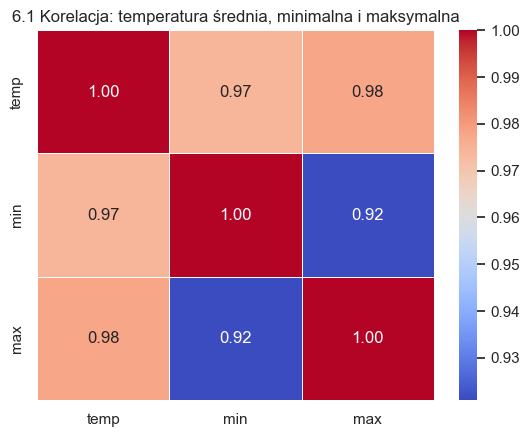

<Figure size 800x600 with 0 Axes>

          temp       min       max
temp  1.000000  0.974326  0.977575
min   0.974326  1.000000  0.920983
max   0.977575  0.920983  1.000000


In [25]:
#6.1
cols_61 = ["temp", "min", "max"]

corr_61 = correlation_heatmap(
    df,
    cols_61,
    "6.1 Korelacja: temperatura średnia, minimalna i maksymalna"
)

print(corr_61)

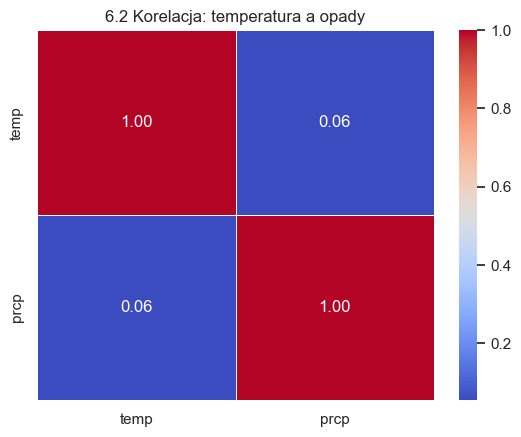

<Figure size 800x600 with 0 Axes>

          temp      prcp
temp  1.000000  0.055738
prcp  0.055738  1.000000


In [26]:
#6.2
cols_62 = ["temp", "prcp"]

corr_62 = correlation_heatmap(
    df,
    cols_62,
    "6.2 Korelacja: temperatura a opady"
)

print(corr_62)

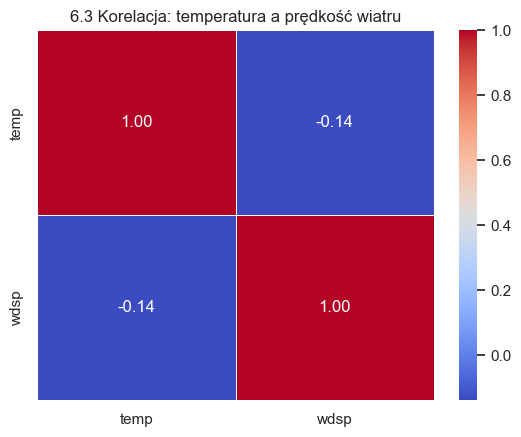

<Figure size 800x600 with 0 Axes>

          temp      wdsp
temp  1.000000 -0.138411
wdsp -0.138411  1.000000


In [27]:
#6.3
cols_63 = ["temp", "wdsp"]

corr_63 = correlation_heatmap(
    df,
    cols_63,
    "6.3 Korelacja: temperatura a prędkość wiatru"
)

print(corr_63)

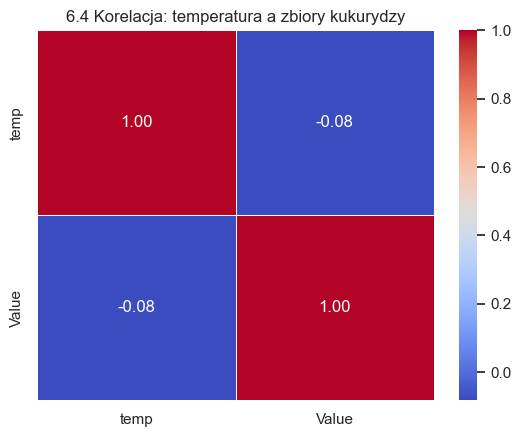

<Figure size 800x600 with 0 Axes>

           temp     Value
temp   1.000000 -0.081667
Value -0.081667  1.000000


In [28]:
#6.4
df_2_c=df_2.copy()
df_2_c["Value"] = df_2_c["Value"].replace("<null>", 0) ########### Czy aby na pewno?? null to chyba brak danych a nie zerowe zbiory

cols_64 = ["temp", "Value"]

df_2_c = df_2_c[(df_2['Item']=='Maize (corn)')].reset_index(drop=True)

corr_64 = correlation_heatmap(
    df_2_c,
    cols_64,
    "6.4 Korelacja: temperatura a zbiory kukurydzy"
)

print(corr_64)

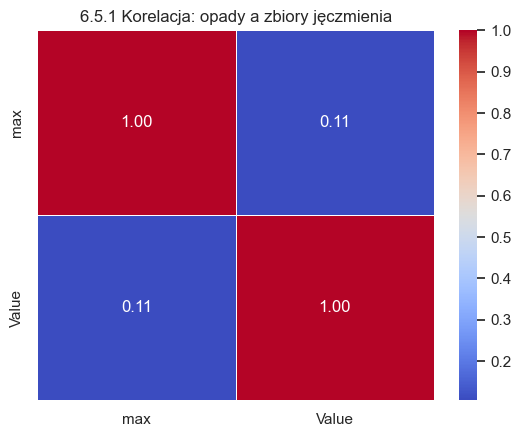

<Figure size 800x600 with 0 Axes>

            max     Value
max    1.000000  0.106154
Value  0.106154  1.000000


In [29]:
#6.5.1
df_2_d=df_2.copy()
df_2_d["Value"] = df_2_d["Value"].replace("<null>", 0)  ########### Czy aby na pewno?? null to chyba brak danych a nie zerowe zbiory

cols_651 = ["max", "Value"]
df_2 = df_2_d[(df_2_d['Item']=='Barley')].reset_index(drop=True)

corr_651 = correlation_heatmap(
    df_2_d,
    cols_651,
    "6.5.1 Korelacja: opady a zbiory jęczmienia"
)

print(corr_651)

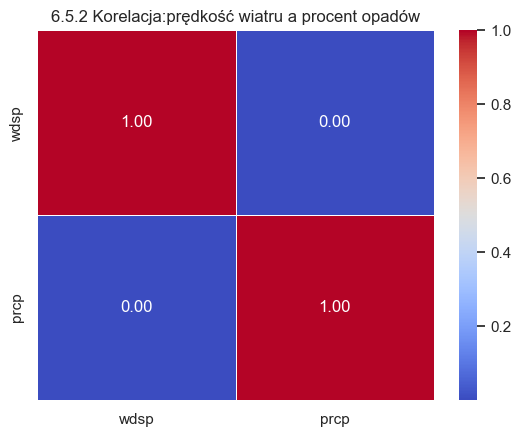

<Figure size 800x600 with 0 Axes>

          wdsp      prcp
wdsp  1.000000  0.000826
prcp  0.000826  1.000000


In [30]:
#6.5.2
cols_652 = ["wdsp","prcp"]

corr_652 = correlation_heatmap(
    df,
    cols_652,
    "6.5.2 Korelacja:prędkość wiatru a procent opadów"
)

print(corr_652)

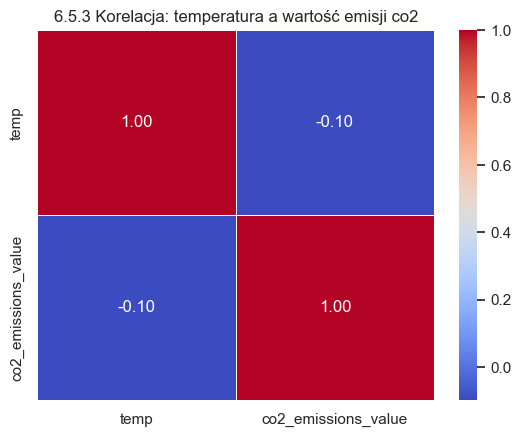

<Figure size 800x600 with 0 Axes>

                         temp  co2_emissions_value
temp                 1.000000            -0.096957
co2_emissions_value -0.096957             1.000000


In [31]:
#6.5.3
cols_653 = ["temp", "co2_emissions_value"]
corr_653 = correlation_heatmap(
    df_3,
    cols_653,
    "6.5.3 Korelacja: temperatura a wartość emisji co2"
)
print(corr_653)

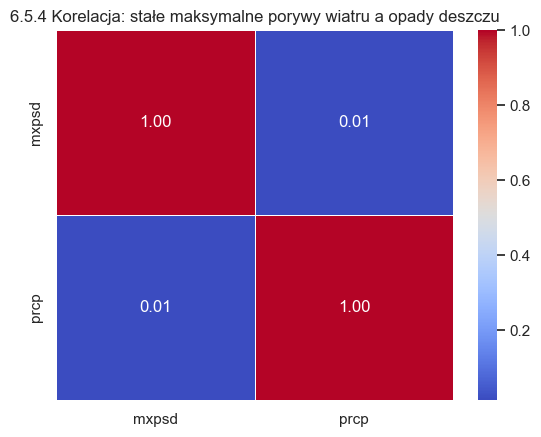

<Figure size 800x600 with 0 Axes>

          mxpsd      prcp
mxpsd  1.000000  0.013458
prcp   0.013458  1.000000


In [32]:
#6.5.4
cols_654 = ["mxpsd", "prcp"]
corr_654 = correlation_heatmap(
    df,
    cols_654,
    "6.5.4 Korelacja: stałe maksymalne porywy wiatru a opady deszczu"
)
print(corr_654)